# Cell 1 — Environment Setup

In [1]:
# Cell 1 — Install Libraries and Mount Google Drive

# Install required library
!pip install tf_keras -q

# Import libraries
import os
import numpy as np
import tf_keras as keras
from tf_keras import layers
from tf_keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("[SUCCESS] Libraries imported and Drive mounted.")

Mounted at /content/drive
[SUCCESS] Libraries imported and Drive mounted.


In [ ]:
!ls /content | grep best_model

best_model.keras.zip


#Cell 2 — File Paths

In [2]:
# Cell 2 — Define File Paths

# Paths to the compressed dataset and saved baseline model in Google Drive
DATASET_ZIP_PATH = "/content/drive/MyDrive/Face mask dataSet.zip"
BASELINE_ZIP_PATH = "/content/drive/MyDrive/best_model.zip"

# Local paths used inside the Colab runtime
DATASET_DIR = "/content/mask_dataset"
BASELINE_MODEL_PATH = "/content/best_model.keras"

# Display paths for verification
print("Dataset zip path:", DATASET_ZIP_PATH)
print("Baseline zip path:", BASELINE_ZIP_PATH)

Dataset zip path: /content/drive/MyDrive/Face mask dataSet.zip
Baseline zip path: /content/drive/MyDrive/best_model.zip


#Cell 3 — Extract and Prepare Files

In [3]:
# Cell 3 — Extract Dataset and Prepare Baseline Model

# Remove old dataset folder if it already exists
!rm -rf /content/mask_dataset

# Create a new dataset directory
!mkdir -p /content/mask_dataset

# Extract the compressed dataset into the local Colab directory
!unzip -q "$DATASET_ZIP_PATH" -d "$DATASET_DIR"

# Copy the saved baseline model into the Colab runtime
!cp "$BASELINE_ZIP_PATH" /content/best_model.keras

print("[SUCCESS] Dataset unzipped and model copied as .keras file.")

[SUCCESS] Dataset unzipped and model copied as .keras file.


#Cell 4 — Check Extracted Files

In [4]:
# Cell 4 — Verify Extracted Dataset and Baseline Model

# Display folders inside the extracted dataset directory
print("Inside dataset folder:")
print(os.listdir(DATASET_DIR))

# Verify that the baseline model file exists
print("\nBaseline model exists:")
print(os.path.exists(BASELINE_MODEL_PATH))

Inside dataset folder:
['Face Mask Dataset']

Baseline model exists:
True


#Cell 5 — Set Correct Dataset Paths

In [5]:
# Cell 5 — Define Final Dataset and Model Paths

# Final dataset paths after extraction
VAL_DIR = "/content/mask_dataset/Face Mask Dataset/Validation"
TEST_DIR = "/content/mask_dataset/Face Mask Dataset/Test"

# Baseline model path
WEIGHTS_PATH = "/content/best_model.keras"

# Verify dataset and model paths
print("Validation path exists:", os.path.exists(VAL_DIR))
print("Test path exists:", os.path.exists(TEST_DIR))
print("Weights path exists:", os.path.exists(WEIGHTS_PATH))

# Display dataset class folders
print("\nValidation classes:", os.listdir(VAL_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Validation path exists: True
Test path exists: True
Weights path exists: True

Validation classes: ['WithMask', 'WithoutMask']
Test classes: ['WithMask', 'WithoutMask']


#Cell 6 — Data Loaders

In [6]:
# Cell 6 — Data Loaders

def get_data_loaders(batch_size):
    """
    This function prepares validation and test data.

    Validation:
    Used for tuning / improvement experiments.

    Test:
    Used for final evaluation.
    """

    # Normalize pixel values from [0,255] to [0,1]
    val_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    # Load validation images from directory
    val_generator = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )

     # Load test images from directory
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    return val_generator, test_generator

print("[SUCCESS] Data loader function is ready.")

[SUCCESS] Data loader function is ready.


#Cell 7 — Build Baseline Model from Saved Weights

In [7]:
# Cell 7 — Build Baseline Model from Saved Weights

# Load the full baseline model saved after original training
def load_baseline_model():

   # Load saved .keras model without recompiling
    model = keras.models.load_model(
        "/content/best_model.keras",
        compile=False
    )

    # Recompile model for evaluation and future fine-tuning
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("[SUCCESS] Full baseline model loader is ready.")

[SUCCESS] Full baseline model loader is ready.


#Cell 8 — Evaluation Function

In [8]:
# Cell 8 — Evaluation Function

def evaluate_model(model, test_generator):

    """
    Evaluate the model on the test set using standard classification metrics:
    accuracy, precision, recall, F1-score, and confusion matrix.
    """

    # Evaluate the model and obtain test loss and accuracy
    test_loss, test_accuracy = model.evaluate(test_generator)

    # Generate model predictions on the test set
    predictions = model.predict(test_generator)

     # Convert predicted probabilities into class labels
    y_pred = np.argmax(predictions, axis=1)

    # Get the true class labels from the test generator
    y_true = test_generator.classes

    # Display test accuracy and loss
    print("\n========== Evaluation Results ==========")
    print("Test Accuracy:", test_accuracy)
    print("Test Loss:", test_loss)

    # Display precision, recall, and F1-score for each class
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    ))


# Confusion Matrix Visualization
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(test_generator.class_indices.keys())
    )

    disp.plot(
        cmap="Blues",
        ax=ax,
        values_format="d"
    )

    plt.title("Confusion Matrix")

    plt.show()

    return test_accuracy, test_loss



print("[SUCCESS] Evaluation function is ready.")

[SUCCESS] Evaluation function is ready.


#Cell 9 — Baseline Check Before Any Improvement

Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
31/31 [==============================] - 4s 103ms/step

========== Evaluation Results ==========
Test Accuracy: 0.9909273982048035
Test Loss: 0.03190429136157036

Classification Report:
              precision    recall  f1-score   support

    WithMask       0.99      0.99      0.99       483
 WithoutMask       0.99      0.99      0.99       509

    accuracy                           0.99       992
   macro avg       0.99      0.99      0.99       992
weighted avg       0.99      0.99      0.99       992



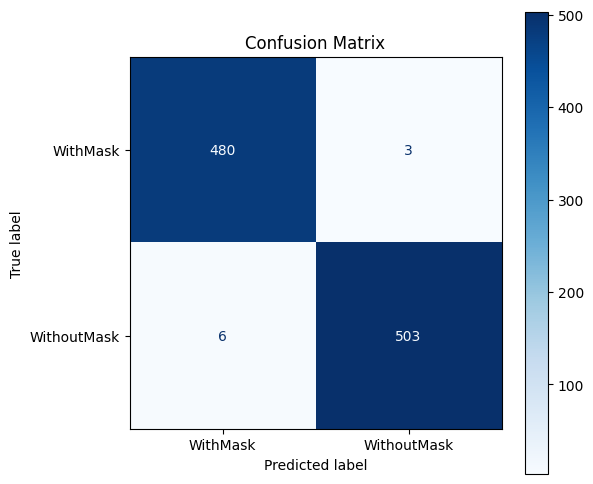

In [9]:
# Cell 9 — Baseline Check Before Any Improvement

# Define batch size for loading the dataset
BATCH_SIZE = 32

# Prepare validation and test data generators
val_gen, test_gen = get_data_loaders(BATCH_SIZE)

# Load the pretrained baseline model
baseline_model = load_baseline_model()

# Evaluate the baseline model on the test set
baseline_acc, baseline_loss = evaluate_model(baseline_model, test_gen)

#Improvement Experiments

**Part A — Model and Input-Based Improvements**

In [ ]:
# Cell 10 — Improvement 1: Regularization Model

def build_regularization_model():
    """
    Load the saved baseline model and add regularization-based improvements:
    1. Batch Normalization
    2. Dropout
    3. L2 Regularization
    """

    # Load the full baseline model with trained weights
    baseline_model = load_baseline_model()

    # Freeze the original baseline layers
    for layer in baseline_model.layers:
        layer.trainable = False

    # Use the layer before the original output layer as feature representation
    x = baseline_model.layers[-2].output

    # Improvement 1: Batch Normalization
    x = layers.BatchNormalization()(x)

    # Improvement 2: Dropout
    x = layers.Dropout(0.2)(x)

    # Improvement 3: L2 Regularization
    output = layers.Dense(
        2,
        activation="softmax",
        kernel_regularizer=keras.regularizers.l2(0.0001),
        name="regularized_fc_mask"
    )(x)

    # Build the improved model
    model = keras.Model(
        inputs=baseline_model.input,
        outputs=output
    )

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("[SUCCESS] Regularization model builder is ready.")

[SUCCESS] Regularization model builder is ready.


Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
25/25 [==============================] - 9s 137ms/step - loss: 0.9305 - accuracy: 0.5225
Epoch 2/50
25/25 [==============================] - 3s 115ms/step - loss: 0.5257 - accuracy: 0.7525
Epoch 3/50
25/25 [==============================] - 3s 116ms/step - loss: 0.3873 - accuracy: 0.8363
Epoch 4/50
25/25 [==============================] - 3s 116ms/step - loss: 0.3813 - accuracy: 0.8425
Epoch 5/50
25/25 [==============================] - 3s 123ms/step - loss: 0.3160 - accuracy: 0.8637
Epoch 6/50
25/25 [==============================] - 4s 138ms/step - loss: 0.2927 - accuracy: 0.8813
Epoch 7/50
25/25 [==============================] - 3s 134ms/step - loss: 0.2790 - accuracy: 0.8850
Epoch 8/50
25/25 [==============================] - 3s 121ms/step - loss: 0.2712 - accuracy: 0.8988
Epoch 9/50
25/25 [==============================] - 3s 118ms/step - loss: 0.2363 - accuracy: 0.9075
Epoch 10/50
25/25 

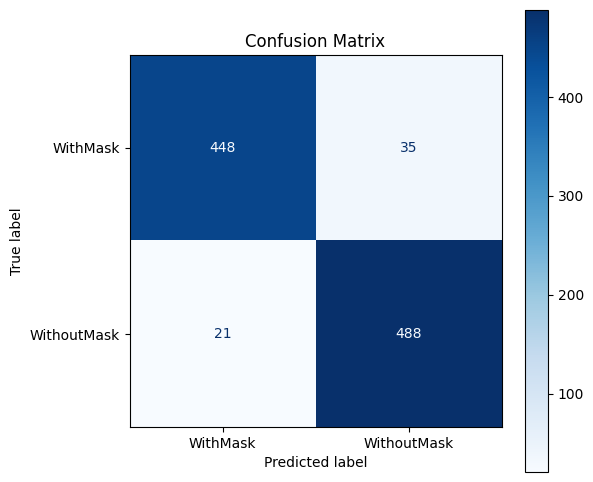

In [ ]:
# Cell 11 — Fine-Tuning and Evaluation: Regularization

EPOCHS = 50
BATCH_SIZE = 32

val_gen, test_gen = get_data_loaders(BATCH_SIZE)

regularization_model = build_regularization_model()

# Stop training if validation loss does not improve
early_stopping = keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_regularization = regularization_model.fit(
    val_gen,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

regularization_acc, regularization_loss = evaluate_model(
    regularization_model,
    test_gen
)

In [ ]:
# Cell 12 — Unified Factory for Data Loaders and Model Building

def create_experiment_loader(target_size, color_mode='rgb', batch_size=32):
    """Generates validation and test data loaders dynamically based on target specs."""
    datagen = ImageDataGenerator(rescale=1./255)

    val_gen = datagen.flow_from_directory(VAL_DIR, target_size=target_size, batch_size=batch_size, class_mode='categorical', color_mode=color_mode, shuffle=True)
    test_gen = datagen.flow_from_directory(TEST_DIR, target_size=target_size, batch_size=batch_size, class_mode='categorical', color_mode=color_mode, shuffle=False)
    return val_gen, test_gen


def build_frozen_experiment_model(input_shape, needs_channel_expansion=False):
    """Loads the pure baseline model, freezes it, and adjusts the input architecture."""
    baseline_model = load_baseline_model()

    # Strict 100% freezing of baseline weights
    for layer in baseline_model.layers:
        layer.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # Check if Grayscale needs channel expansion (1 to 3 channels)
    if needs_channel_expansion:
        x = layers.Concatenate(axis=-1)([input_layer, input_layer, input_layer])
    else:
        x = input_layer

    # Resize input internally to match baseline expectations (224x224)
    resized_input = layers.Resizing(224, 224)(x)
    output_layer = baseline_model(resized_input)

    # Assemble and compile the experimental model using direct learning rate matching baseline
    model = keras.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Triggering the Architecture Building with Success Logs
print("[INFO] Constructing all experimental models...")

# Build Low Resolution Method
model_low_res = build_frozen_experiment_model(input_shape=(108, 108, 3), needs_channel_expansion=False)
print("[SUCCESS] Low Resolution Method Model Built and Frozen Successfully!")

# Build High Resolution Method
model_high_res = build_frozen_experiment_model(input_shape=(300, 300, 3), needs_channel_expansion=False)
print("[SUCCESS] High Resolution Method Model Built and Frozen Successfully!")

# Build Grayscale Method
model_grayscale = build_frozen_experiment_model(input_shape=(224, 224, 1), needs_channel_expansion=True)
print("[SUCCESS] Grayscale Method Model Built and Frozen Successfully!")

[INFO] Constructing all experimental models...
[SUCCESS] Low Resolution Method Model Built and Frozen Successfully!
[SUCCESS] High Resolution Method Model Built and Frozen Successfully!
[SUCCESS] Grayscale Method Model Built and Frozen Successfully!


Executing Low Resolution Method Experiment
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
25/25 [==============================] - 5s 114ms/step - loss: 0.1086 - accuracy: 0.9563
Epoch 2/50
25/25 [==============================] - 3s 97ms/step - loss: 0.1086 - accuracy: 0.9563
Epoch 3/50
25/25 [==============================] - 2s 97ms/step - loss: 0.1086 - accuracy: 0.9563
Epoch 4/50
25/25 [==============================] - 2s 97ms/step - loss: 0.1086 - accuracy: 0.9563
Epoch 5/50
25/25 [==============================] - 3s 99ms/step - loss: 0.1086 - accuracy: 0.9563
Epoch 6/50
25/25 [==============================] - 3s 103ms/step - loss: 0.1086 - accuracy: 0.9563
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
31/31 [==============================] - 4s 96ms/step

========== Evaluation Results ==========
Test Accuracy: 0.9546371102333069
Test Loss: 0.11228223890066147

Classification Report:
           

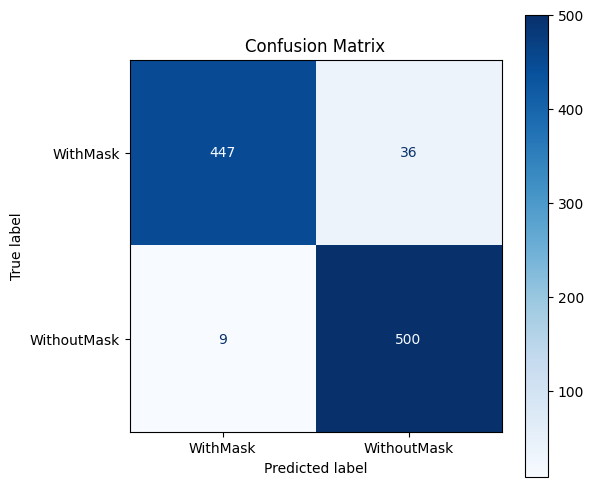

In [ ]:
# Cell 13 — Improvement 2: Low Resolution Method (108x108)

print("Executing Low Resolution Method Experiment")
EPOCHS = 50
BATCH_SIZE = 32

# 1. Get the custom 108x108 data loaders
val_gen_t1, test_gen_t1 = create_experiment_loader(target_size=(108, 108), color_mode='rgb', batch_size=BATCH_SIZE)

# 2. Define early stopping
early_stopping_t1 = keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Train the already built Low Resolution model
history_low_res = model_low_res.fit(
    val_gen_t1,
    epochs=EPOCHS,
    callbacks=[early_stopping_t1]
)

# 4. Evaluate and plot confusion matrix
low_res_acc, low_res_loss = evaluate_model(model_low_res, test_gen_t1)

Executing High Resolution Method Experiment
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
25/25 [==============================] - 7s 146ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 2/50
25/25 [==============================] - 4s 138ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 3/50
25/25 [==============================] - 4s 142ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 4/50
25/25 [==============================] - 4s 150ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 5/50
25/25 [==============================] - 3s 135ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 6/50
25/25 [==============================] - 3s 129ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 7/50
25/25 [==============================] - 4s 138ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 8/50
25/25 [==============================] - 4s 154ms/step - loss: 0.0377 - accuracy: 0.9862
Epoch 9/50
25/25 [==============================] - 3s 125ms/step - loss: 

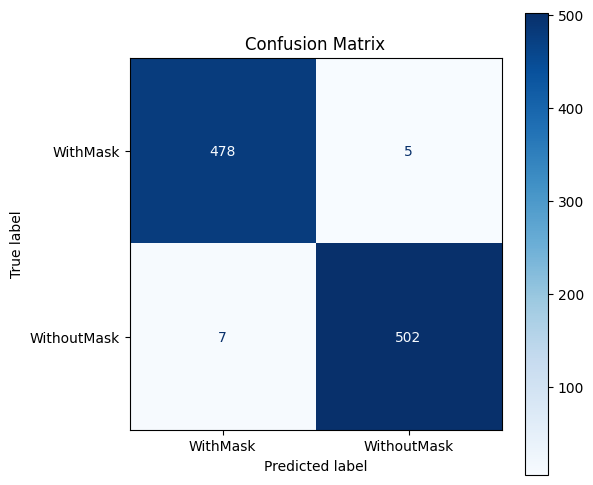

In [ ]:
# Cell 14 — Improvement 3: High Resolution Method (300x300)

print("Executing High Resolution Method Experiment")
EPOCHS = 50
BATCH_SIZE = 32

# 1. Get the custom 300x300 data loaders
val_gen_t2, test_gen_t2 = create_experiment_loader(target_size=(300, 300), color_mode='rgb', batch_size=BATCH_SIZE)

# 2. Define early stopping
early_stopping_t2 = keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Train the already built High Resolution model
history_high_res = model_high_res.fit(
    val_gen_t2,
    epochs=EPOCHS,
    callbacks=[early_stopping_t2]
)

# 4. Evaluate and plot confusion matrix
high_res_acc, high_res_loss = evaluate_model(model_high_res, test_gen_t2)

Executing Grayscale Method Experiment
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
25/25 [==============================] - 7s 111ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 2/50
25/25 [==============================] - 2s 97ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 3/50
25/25 [==============================] - 3s 103ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 4/50
25/25 [==============================] - 2s 98ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 5/50
25/25 [==============================] - 3s 103ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 6/50
25/25 [==============================] - 3s 101ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 7/50
25/25 [==============================] - 3s 104ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 8/50
25/25 [==============================] - 3s 99ms/step - loss: 0.8048 - accuracy: 0.7063
Epoch 9/50
25/25 [==============================] - 3s 99ms/step - loss: 0.8048 - a

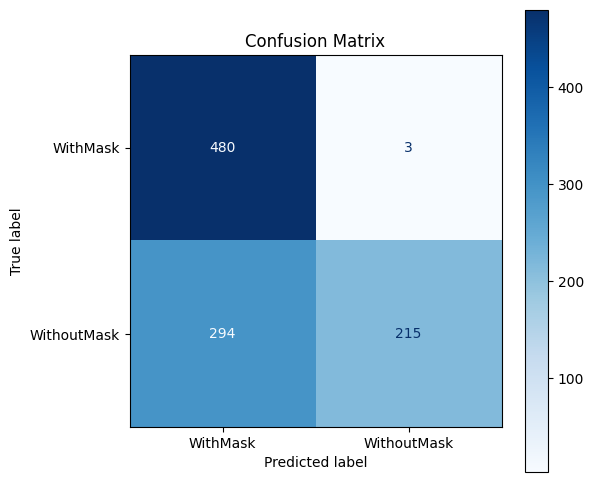

In [ ]:
# Cell 15 — Improvement 4: Grayscale Method (224x224)

print("Executing Grayscale Method Experiment")
EPOCHS = 50
BATCH_SIZE = 32

# 1. Get the custom 224x224 grayscale data loaders (1-channel)
val_gen_t3, test_gen_t3 = create_experiment_loader(target_size=(224, 224), color_mode='grayscale', batch_size=BATCH_SIZE)

# 2. Define early stopping
early_stopping_t3 = keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Train the already built Grayscale model
history_grayscale = model_grayscale.fit(
    val_gen_t3,
    epochs=EPOCHS,
    callbacks=[early_stopping_t3]
)

# 4. Evaluate and plot confusion matrix
grayscale_acc, grayscale_loss = evaluate_model(model_grayscale, test_gen_t3)

**Part B — Training Strategy Optimization**

In [ ]:
# Cell 16 — Gradient Descent Optimization Framework

def run_gradient_descent_strategy(method_name, batch_size, trainable_last_layers=1, epochs=50, learning_rate=0.001):
    """
    Compare Gradient Descent strategies by changing batch size only.

    Stochastic GD  : batch_size = 1
    Mini-Batch GD  : batch_size = 128
    Full-Batch GD  : batch_size = 800

    The baseline optimizer Adam is used to keep the experiment consistent
    with the original baseline settings.
    """

    print(f"\n========== Running {method_name} | Batch Size: {batch_size} | Trainable Layers: {trainable_last_layers} ==========")

    # Prepare data loaders using the selected batch size
    val_gen, test_gen = get_data_loaders(batch_size)

    # Load the saved baseline model
    model = load_baseline_model()

    # Freeze all layers first
    for layer in model.layers:
        layer.trainable = False

    # Unfreeze selected last layers
    for layer in model.layers[-trainable_last_layers:]:
        layer.trainable = True

    # Use Adam to match the baseline optimizer
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping to prevent unnecessary training
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    # Fine-tune on validation set
    history = model.fit(
        val_gen,
        epochs=epochs,
        callbacks=[early_stopping]
    )

    # Evaluate on test set
    acc, loss = evaluate_model(model, test_gen)

    return {
        "GD Strategy": method_name,
        "Batch Size": batch_size,
        "Trainable Layers": trainable_last_layers,
        "Test Accuracy": acc,
        "Test Loss": loss,
        "history": history
    }

print("[SUCCESS] Gradient Descent strategy function is ready.")

[SUCCESS] Gradient Descent strategy function is ready.



========== Running Stochastic GD | Batch Size: 1 | Trainable Layers: 1 ==========
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
800/800 [==============================] - 15s 14ms/step - loss: 0.0726 - accuracy: 0.9725
Epoch 2/50
800/800 [==============================] - 10s 12ms/step - loss: 0.0524 - accuracy: 0.9825
Epoch 3/50
800/800 [==============================] - 11s 14ms/step - loss: 0.0591 - accuracy: 0.9688
Epoch 4/50
800/800 [==============================] - 17s 21ms/step - loss: 0.0410 - accuracy: 0.9875
Epoch 5/50
800/800 [==============================] - 19s 23ms/step - loss: 0.0208 - accuracy: 0.9937
Epoch 6/50
800/800 [==============================] - 12s 14ms/step - loss: 0.0361 - accuracy: 0.9875
Epoch 7/50
800/800 [==============================] - 11s 14ms/step - loss: 0.0081 - accuracy: 1.0000
Epoch 8/50
800/800 [==============================] - 11s 14ms/step - loss: 0.0258 - accuracy: 0.9925
Epoch 9/50
800/800 

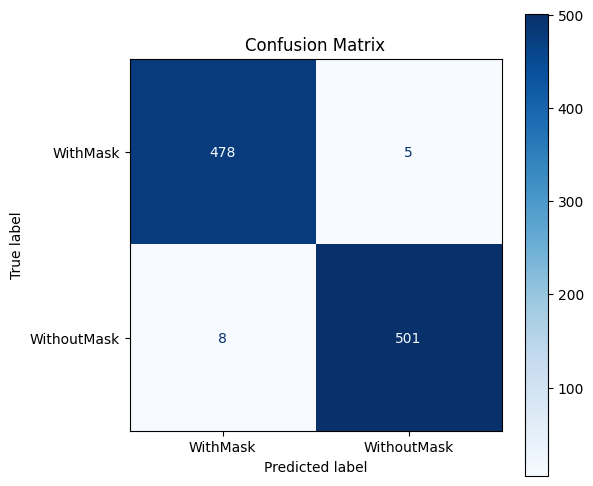

In [ ]:
# Cell 17 — Improvement 5: Stochastic Gradient Descent (Baseline Fine-Tuning)

# Baseline training settings
EPOCHS = 50
LR = 0.001

# Run Stochastic Gradient Descent experiment
stochastic_last1 = run_gradient_descent_strategy(
    method_name="Stochastic GD",
    batch_size=1,
    trainable_last_layers=1,
    epochs=EPOCHS,
    learning_rate=LR
)


========== Running Mini-Batch GD | Batch Size: 128 | Trainable Layers: 1 ==========
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
7/7 [==============================] - 11s 437ms/step - loss: 0.0311 - accuracy: 0.9912
Epoch 2/50
7/7 [==============================] - 3s 409ms/step - loss: 0.0253 - accuracy: 0.9900
Epoch 3/50
7/7 [==============================] - 3s 440ms/step - loss: 0.0233 - accuracy: 0.9925
Epoch 4/50
7/7 [==============================] - 3s 422ms/step - loss: 0.0224 - accuracy: 0.9912
Epoch 5/50
7/7 [==============================] - 3s 430ms/step - loss: 0.0177 - accuracy: 0.9950
Epoch 6/50
7/7 [==============================] - 3s 534ms/step - loss: 0.0163 - accuracy: 0.9962
Epoch 7/50
7/7 [==============================] - 4s 464ms/step - loss: 0.0151 - accuracy: 0.9950
Epoch 8/50
7/7 [==============================] - 4s 446ms/step - loss: 0.0138 - accuracy: 0.9975
Epoch 9/50
7/7 [==============================] 

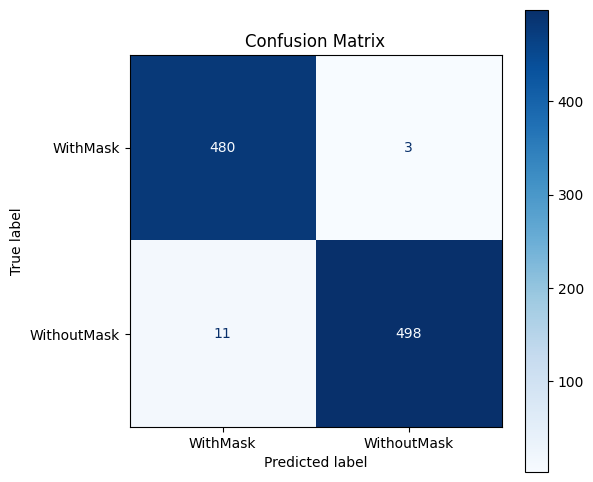

In [ ]:
# Cell 18 — Improvement 6: Mini-Batch Gradient Descent (Baseline Fine-Tuning)

# Run Mini-Batch Gradient Descent experiment
mini_batch_last1 = run_gradient_descent_strategy(
    method_name="Mini-Batch GD",
    batch_size=128,
    trainable_last_layers=1,
    epochs=EPOCHS,
    learning_rate=LR
)


========== Running Full-Batch GD | Batch Size: 800 | Trainable Layers: 1 ==========
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
1/1 [==============================] - 32s 32s/step - loss: 0.0298 - accuracy: 0.9887
Epoch 2/50
1/1 [==============================] - 6s 6s/step - loss: 0.0317 - accuracy: 0.9887
Epoch 3/50
1/1 [==============================] - 5s 5s/step - loss: 0.0271 - accuracy: 0.9900
Epoch 4/50
1/1 [==============================] - 5s 5s/step - loss: 0.0258 - accuracy: 0.9912
Epoch 5/50
1/1 [==============================] - 5s 5s/step - loss: 0.0258 - accuracy: 0.9925
Epoch 6/50
1/1 [==============================] - 5s 5s/step - loss: 0.0242 - accuracy: 0.9925
Epoch 7/50
1/1 [==============================] - 5s 5s/step - loss: 0.0223 - accuracy: 0.9937
Epoch 8/50
1/1 [==============================] - 5s 5s/step - loss: 0.0215 - accuracy: 0.9937
Epoch 9/50
1/1 [==============================] - 5s 5s/step - loss: 0.

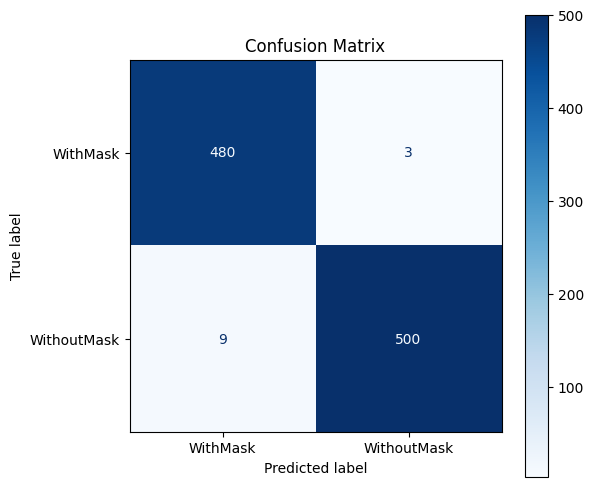

In [ ]:
# Cell 19 — Improvement 7: Full-Batch Gradient Descent (Baseline Fine-Tuning)

# Run Full-Batch Gradient Descent experiment
full_batch_last1 = run_gradient_descent_strategy(
    method_name="Full-Batch GD",
    batch_size=800,
    trainable_last_layers=1,
    epochs=EPOCHS,
    learning_rate=LR
)


========== Running Stochastic GD | Batch Size: 1 | Trainable Layers: 5 ==========
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
800/800 [==============================] - 15s 14ms/step - loss: 0.0749 - accuracy: 0.9700
Epoch 2/50
800/800 [==============================] - 18s 22ms/step - loss: 0.0490 - accuracy: 0.9837
Epoch 3/50
800/800 [==============================] - 15s 18ms/step - loss: 0.0393 - accuracy: 0.9875
Epoch 4/50
800/800 [==============================] - 10s 13ms/step - loss: 0.0329 - accuracy: 0.9862
Epoch 5/50
800/800 [==============================] - 11s 14ms/step - loss: 0.0230 - accuracy: 0.9937
Epoch 6/50
800/800 [==============================] - 11s 14ms/step - loss: 0.0224 - accuracy: 0.9912
Epoch 7/50
800/800 [==============================] - 12s 15ms/step - loss: 0.0078 - accuracy: 0.9987
Epoch 8/50
800/800 [==============================] - 11s 13ms/step - loss: 0.0189 - accuracy: 0.9962
Epoch 9/50
800/800 

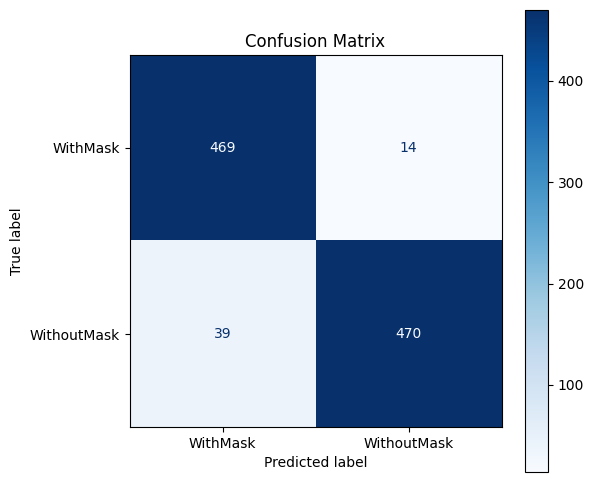

In [ ]:
# Cell 20 — Improvement 8: Stochastic Gradient Descent (Last 5 Trainable Layers)

# Run Stochastic Gradient Descent with partial fine-tuning
stochastic_last5 = run_gradient_descent_strategy(
    method_name="Stochastic GD",
    batch_size=1,
    trainable_last_layers=5,
    epochs=EPOCHS,
    learning_rate=LR
)


========== Running Mini-Batch GD | Batch Size: 128 | Trainable Layers: 5 ==========
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
7/7 [==============================] - 8s 458ms/step - loss: 0.0738 - accuracy: 0.9775
Epoch 2/50
7/7 [==============================] - 3s 523ms/step - loss: 0.0511 - accuracy: 0.9812
Epoch 3/50
7/7 [==============================] - 3s 442ms/step - loss: 0.0434 - accuracy: 0.9862
Epoch 4/50
7/7 [==============================] - 4s 442ms/step - loss: 0.0410 - accuracy: 0.9887
Epoch 5/50
7/7 [==============================] - 3s 447ms/step - loss: 0.0296 - accuracy: 0.9875
Epoch 6/50
7/7 [==============================] - 4s 465ms/step - loss: 0.0260 - accuracy: 0.9912
Epoch 7/50
7/7 [==============================] - 4s 492ms/step - loss: 0.0239 - accuracy: 0.9900
Epoch 8/50
7/7 [==============================] - 4s 466ms/step - loss: 0.0219 - accuracy: 0.9925
Epoch 9/50
7/7 [==============================] -

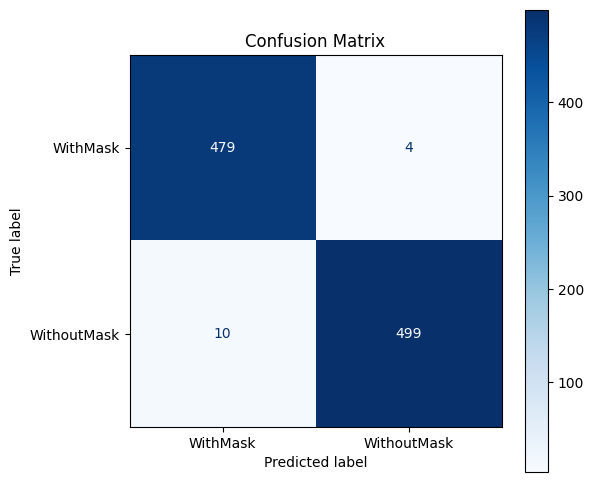

In [ ]:
# Cell 21 — Improvement 9: Mini-Batch Gradient Descent (Last 5 Trainable Layers)

# Run Mini-Batch Gradient Descent with partial fine-tuning
mini_batch_last5 = run_gradient_descent_strategy(
    method_name="Mini-Batch GD",
    batch_size=128,
    trainable_last_layers=5,
    epochs=EPOCHS,
    learning_rate=LR
)


========== Running Full-Batch GD | Batch Size: 800 | Trainable Layers: 5 ==========
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
1/1 [==============================] - 8s 8s/step - loss: 0.1630 - accuracy: 0.9588
Epoch 2/50
1/1 [==============================] - 6s 6s/step - loss: 0.0969 - accuracy: 0.9688
Epoch 3/50
1/1 [==============================] - 5s 5s/step - loss: 0.0619 - accuracy: 0.9800
Epoch 4/50
1/1 [==============================] - 5s 5s/step - loss: 0.0526 - accuracy: 0.9812
Epoch 5/50
1/1 [==============================] - 5s 5s/step - loss: 0.0596 - accuracy: 0.9825
Epoch 6/50
1/1 [==============================] - 5s 5s/step - loss: 0.0702 - accuracy: 0.9762
Epoch 7/50
1/1 [==============================] - 5s 5s/step - loss: 0.0742 - accuracy: 0.9750
Epoch 8/50
1/1 [==============================] - 5s 5s/step - loss: 0.0697 - accuracy: 0.9762
Epoch 9/50
1/1 [==============================] - 5s 5s/step - loss: 0.06

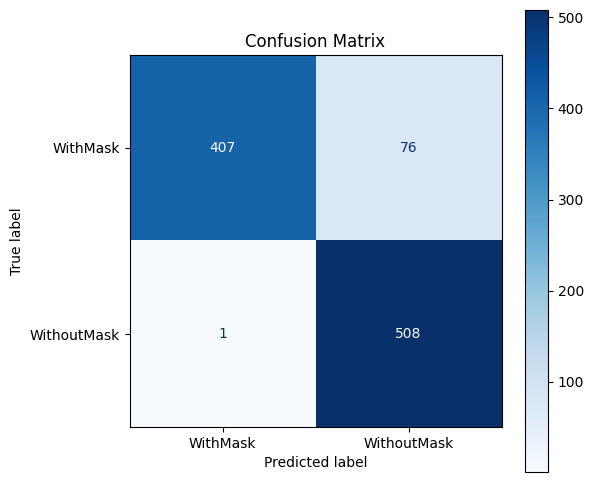

In [ ]:
# Cell 22 — Improvement 10: Full-Batch Gradient Descent (Last 5 Trainable Layers)

# Run Full-Batch Gradient Descent with partial fine-tuning
full_batch_last5 = run_gradient_descent_strategy(
    method_name="Full-Batch GD",
    batch_size=800,
    trainable_last_layers=5,
    epochs=EPOCHS,
    learning_rate=LR
)


========== Gradient Descent Results ==========

Gradient Strategy  Batch Size  Trainable Layers  Accuracy (%)   Loss
    Stochastic GD           1                 1         98.69 0.0538
    Mini-Batch GD         128                 1         98.59 0.0432
    Full-Batch GD         800                 1         98.79 0.0359
    Stochastic GD           1                 5         94.66 0.4987
    Mini-Batch GD         128                 5         98.59 0.0449
    Full-Batch GD         800                 5         92.24 0.1895




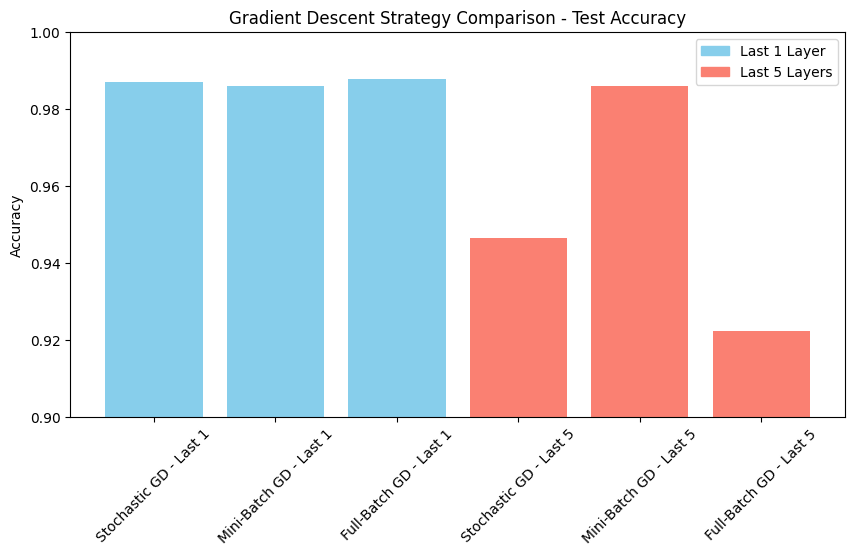

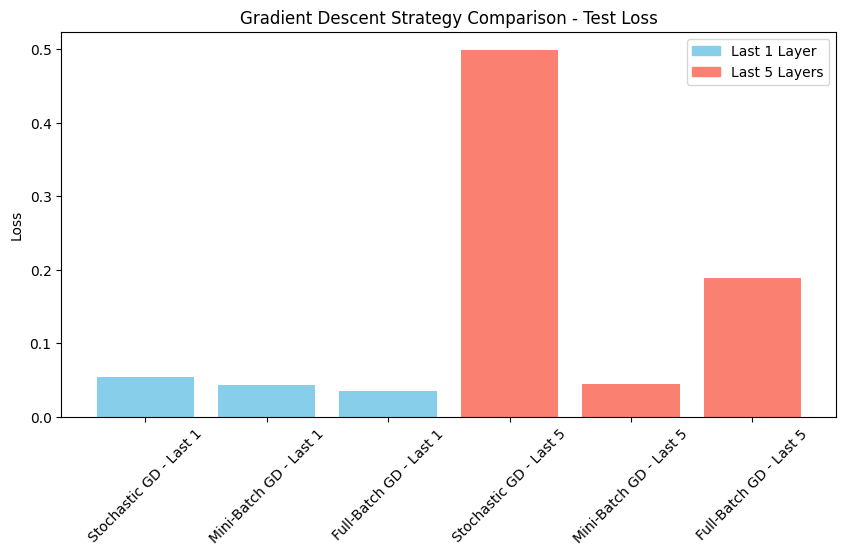

In [ ]:
# Cell 23 — Gradient Descent Results Comparison

import pandas as pd
import matplotlib.pyplot as plt

# Collect all gradient descent experiment results
gd_results = [
    stochastic_last1,
    mini_batch_last1,
    full_batch_last1,
    stochastic_last5,
    mini_batch_last5,
    full_batch_last5
]

# Create results dataframe without the training history column
gd_df = pd.DataFrame([
    {
        "GD Strategy": r["GD Strategy"],
        "Batch Size": r["Batch Size"],
        "Trainable Layers": r["Trainable Layers"],
        "Test Accuracy": r["Test Accuracy"],
        "Test Loss": r["Test Loss"]
    }
    for r in gd_results
])

# Create a formatted table
display_df = gd_df.copy()
display_df["Test Accuracy"] = (display_df["Test Accuracy"] * 100).round(2)
display_df["Test Loss"] = display_df["Test Loss"].round(4)

display_df = display_df.rename(columns={
    "GD Strategy": "Gradient Strategy",
    "Test Accuracy": "Accuracy (%)",
    "Test Loss": "Loss"
})

print("\n========== Gradient Descent Results ==========\n")
print(display_df.to_string(index=False))

# Prepare labels and colors
labels = (
    gd_df["GD Strategy"]
    + " - Last "
    + gd_df["Trainable Layers"].astype(str)
)

colors = [
    "skyblue" if layer == 1 else "salmon"
    for layer in gd_df["Trainable Layers"]
]

# Add spacing before visualizations
print("\n" * 1)

# Accuracy comparison
plt.figure(figsize=(10, 5))
plt.bar(labels, gd_df["Test Accuracy"], color=colors)
plt.title("Gradient Descent Strategy Comparison - Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.90, 1.0)
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="skyblue", label="Last 1 Layer"),
        plt.Rectangle((0, 0), 1, 1, color="salmon", label="Last 5 Layers")
    ]
)
plt.show()

# Add spacing between figures
print("\n" * 1)

# Loss comparison
plt.figure(figsize=(10, 5))
plt.bar(labels, gd_df["Test Loss"], color=colors)
plt.title("Gradient Descent Strategy Comparison - Test Loss")
plt.ylabel("Loss")
plt.xticks(rotation=45)
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="skyblue", label="Last 1 Layer"),
        plt.Rectangle((0, 0), 1, 1, color="salmon", label="Last 5 Layers")
    ]
)
plt.show()

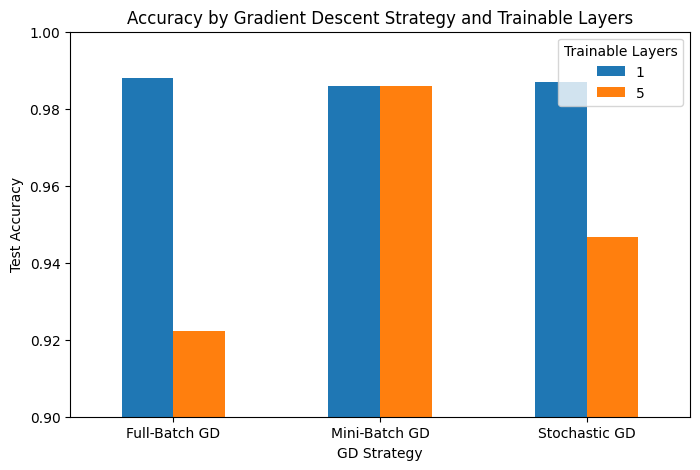

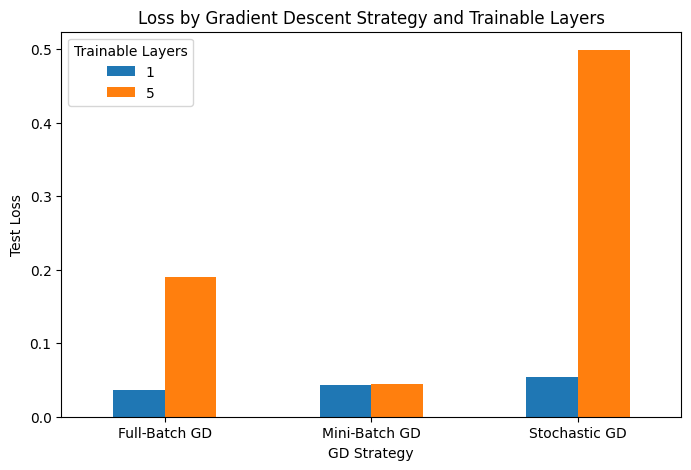

In [ ]:
# Cell 24 — Convergence and Stability Analysis

# Grouped Accuracy Comparison by GD Strategy

# Create pivot table for accuracy comparison
pivot_acc = gd_df.pivot(
    index="GD Strategy",
    columns="Trainable Layers",
    values="Test Accuracy"
)

# Plot grouped accuracy comparison
pivot_acc.plot(kind="bar", figsize=(8,5))

plt.title("Accuracy by Gradient Descent Strategy and Trainable Layers")
plt.ylabel("Test Accuracy")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=0)

plt.legend(title="Trainable Layers")

plt.show()

# Add spacing between visualizations
print("\n" * 1)

# Grouped Loss Comparison by GD Strategy

# Create pivot table for loss comparison
pivot_loss = gd_df.pivot(
    index="GD Strategy",
    columns="Trainable Layers",
    values="Test Loss"
)

# Plot grouped loss comparison
pivot_loss.plot(kind="bar", figsize=(8,5))

plt.title("Loss by Gradient Descent Strategy and Trainable Layers")
plt.ylabel("Test Loss")
plt.xticks(rotation=0)

plt.legend(title="Trainable Layers")

plt.show()

In [10]:
# Cell 25 — Loss Function Experiment Engine

def run_loss_experiment(loss_type, loss_fn, batch_size=32, epochs=50, class_weight=None):
    """
    Runs a loss function experiment on the face mask dataset.
    Each type applies a different loss modification strategy:

    Type 1 — Focal Loss      : penalizes hard-to-classify examples more heavily
    Type 2 — Label Smoothing : reduces model overconfidence during training
    Type 3 — Class Weighted  : compensates for class distribution imbalance
    """

    print(f"\n[EXPERIMENT] Starting: {loss_type}")

    # Load data generators
    val_generator, test_generator = get_data_loaders(batch_size)

    # Load pretrained baseline weights
    base = load_baseline_model()

    # Freeze all pretrained layers
    for layer in base.layers:
        layer.trainable = False

    # Attach new classification head
    features = base.layers[-2].output
    predictions = layers.Dense(2, activation='softmax')(features)
    experiment_model = keras.Model(inputs=base.input, outputs=predictions)

    # Compile with the specified loss function
    experiment_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss=loss_fn,
        metrics=['accuracy']
    )

    # Define early stopping callback
    stopper = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    # Fine-tune on validation set
    history = experiment_model.fit(
        val_generator,
        validation_data=test_generator,
        epochs=epochs,
        callbacks=[stopper],
        class_weight=class_weight
    )

    # Evaluate on test set
    test_acc, test_loss = evaluate_model(experiment_model, test_generator)

    return {
        'Type'     : loss_type,
        'Accuracy' : test_acc,
        'Loss'     : test_loss,
        'History'  : history
    }

print("[SUCCESS] Loss experiment engine is ready.")

[SUCCESS] Loss experiment engine is ready.



[EXPERIMENT] Starting: Type 1 — Focal Loss
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
25/25 [==============================] - 20s 323ms/step - loss: 0.0554 - accuracy: 0.5888 - val_loss: 0.0415 - val_accuracy: 0.7016
Epoch 2/50
25/25 [==============================] - 7s 273ms/step - loss: 0.0313 - accuracy: 0.7800 - val_loss: 0.0277 - val_accuracy: 0.8034
Epoch 3/50
25/25 [==============================] - 6s 256ms/step - loss: 0.0236 - accuracy: 0.8450 - val_loss: 0.0239 - val_accuracy: 0.8377
Epoch 4/50
25/25 [==============================] - 9s 369ms/step - loss: 0.0208 - accuracy: 0.8750 - val_loss: 0.0202 - val_accuracy: 0.8740
Epoch 5/50
25/25 [==============================] - 6s 260ms/step - loss: 0.0183 - accuracy: 0.8900 - val_loss: 0.0186 - val_accuracy: 0.8810
Epoch 6/50
25/25 [==============================] - 7s 273ms/step - loss: 0.0167 - accuracy: 0.8975 - val_loss: 0.0169 - val_accuracy: 0.9002
Epoch 7/50
25/25 [===

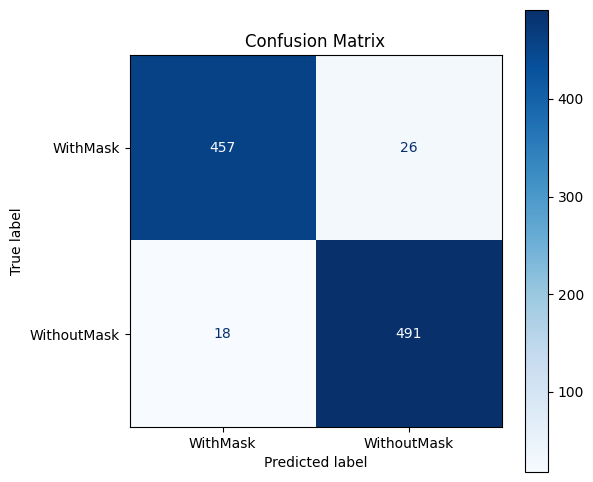

In [11]:
# Cell 26 — Type 1: Focal Loss

import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss: down-weights easy examples so the model
    focuses more on difficult misclassified samples.
    """
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        return tf.reduce_mean(
            tf.reduce_sum(
                alpha * y_true * tf.pow(1.0 - y_pred, gamma) * (-tf.math.log(y_pred)),
                axis=1
            )
        )
    return loss_fn

EPOCHS     = 50
BATCH_SIZE = 32

focal_result = run_loss_experiment(
    loss_type='Type 1 — Focal Loss',
    loss_fn=focal_loss(gamma=2.0, alpha=0.25),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)


[EXPERIMENT] Starting: Type 2 — Label Smoothing
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
25/25 [==============================] - 11s 344ms/step - loss: 0.6766 - accuracy: 0.6587 - val_loss: 0.5735 - val_accuracy: 0.7661
Epoch 2/50
25/25 [==============================] - 7s 270ms/step - loss: 0.5451 - accuracy: 0.7750 - val_loss: 0.4856 - val_accuracy: 0.8306
Epoch 3/50
25/25 [==============================] - 7s 291ms/step - loss: 0.4780 - accuracy: 0.8325 - val_loss: 0.4360 - val_accuracy: 0.8649
Epoch 4/50
25/25 [==============================] - 7s 276ms/step - loss: 0.4367 - accuracy: 0.8637 - val_loss: 0.4061 - val_accuracy: 0.8921
Epoch 5/50
25/25 [==============================] - 7s 283ms/step - loss: 0.4110 - accuracy: 0.8875 - val_loss: 0.3878 - val_accuracy: 0.9103
Epoch 6/50
25/25 [==============================] - 7s 267ms/step - loss: 0.3932 - accuracy: 0.8950 - val_loss: 0.3757 - val_accuracy: 0.9183
Epoch 7/50
25/25

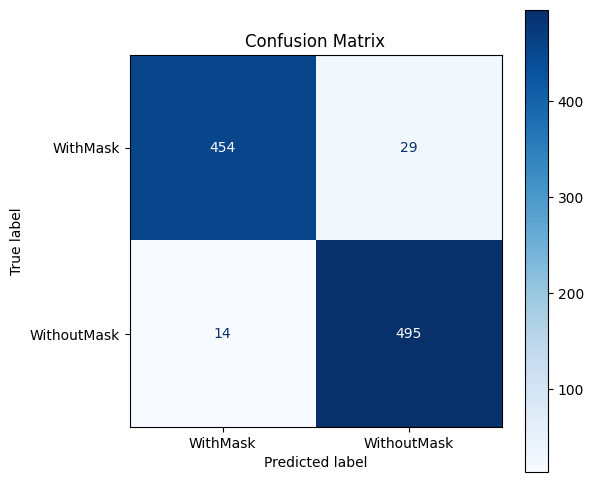

In [12]:
# Cell 27 — Type 2: Label Smoothing

label_smooth_result = run_loss_experiment(
    loss_type='Type 2 — Label Smoothing',
    loss_fn=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
[INFO] Computed class weights: {0: np.float64(1.0), 1: np.float64(1.0)}

[EXPERIMENT] Starting: Type 3 — Class Weighted Loss
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Epoch 1/50
25/25 [==============================] - 13s 391ms/step - loss: 0.4799 - accuracy: 0.8200 - val_loss: 0.3802 - val_accuracy: 0.8972
Epoch 2/50
25/25 [==============================] - 7s 278ms/step - loss: 0.3757 - accuracy: 0.8863 - val_loss: 0.3129 - val_accuracy: 0.9143
Epoch 3/50
25/25 [==============================] - 7s 294ms/step - loss: 0.3255 - accuracy: 0.8963 - val_loss: 0.2797 - val_accuracy: 0.9183
Epoch 4/50
25/25 [==============================] - 7s 271ms/step - loss: 0.2933 - accuracy: 0.9050 - val_loss: 0.2549 - val_accuracy: 0.9274
Epoch 5/50
25/25 [==============================] - 7s 274ms/step - loss: 0.2718 - accuracy: 0.9137 - val_loss: 0.2388 - val_accuracy: 0.9315


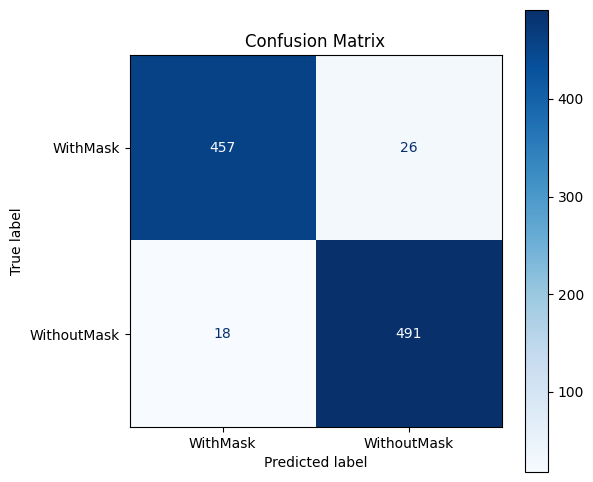

In [13]:
# Cell 28 — Type 3: Class Weighted Loss

from sklearn.utils.class_weight import compute_class_weight

# Compute weights based on class distribution
val_gen, _ = get_data_loaders(BATCH_SIZE)
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(val_gen.classes),
    y=val_gen.classes
)
class_weight_map = dict(enumerate(raw_weights))
print(f"[INFO] Computed class weights: {class_weight_map}")

class_weighted_result = run_loss_experiment(
    loss_type='Type 3 — Class Weighted Loss',
    loss_fn='categorical_crossentropy',
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weight_map
)

Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.

   Loss Function Modifications — Results Summary
                          Accuracy    Loss
Baseline                    0.9909  0.0319
Type 1 — Focal Loss         0.9556  0.0075
Type 2 — Label Smoothing    0.9567  0.2928
Type 3 — Class Weighted     0.9556  0.1164


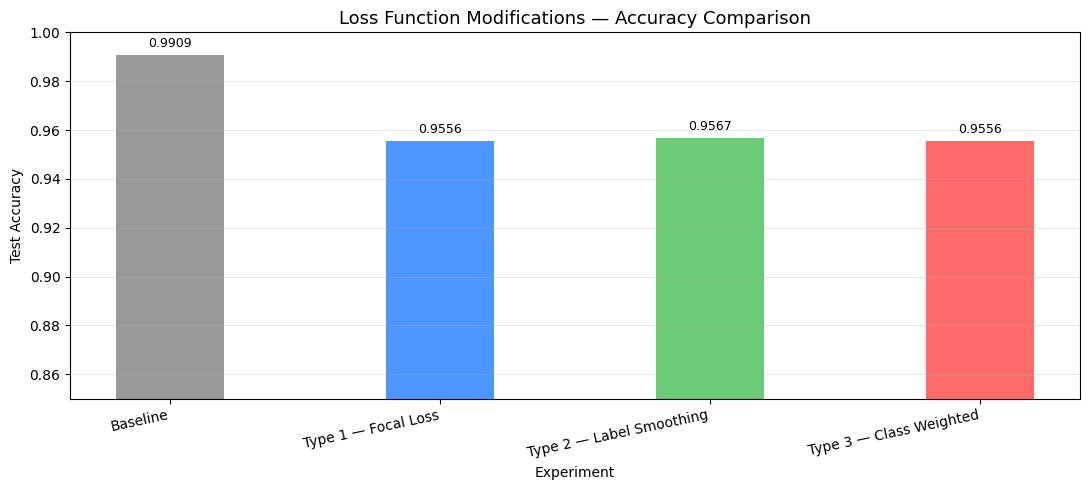

In [14]:
# Cell 29 — Results Summary & Comparison

import pandas as pd

# Collect metrics for all experiments
summary = {}
_, test_gen    = get_data_loaders(32)
baseline_model = load_baseline_model()

for label, result in [
    ("Baseline",                 baseline_model),
    ("Type 1 — Focal Loss",      focal_result),
    ("Type 2 — Label Smoothing", label_smooth_result),
    ("Type 3 — Class Weighted",  class_weighted_result),
]:
    if isinstance(result, dict):
        acc  = result['Accuracy']
        loss = result['Loss']
    else:
        loss, acc = result.evaluate(test_gen, verbose=0)

    summary[label] = {
        'Accuracy' : round(acc,  4),
        'Loss'     : round(loss, 4),
    }

# Print table
df_summary = pd.DataFrame(summary).T
print("\n" + "="*60)
print("   Loss Function Modifications — Results Summary")
print("="*60)
print(df_summary.to_string())
print("="*60)

# Visualization
labels     = list(summary.keys())
accuracies = [summary[m]['Accuracy'] for m in labels]

x, w = np.arange(len(labels)), 0.4
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(x, accuracies, w, color=['#999999', '#4d96ff', '#6bcb77', '#ff6b6b'])

ax.set_title('Loss Function Modifications — Accuracy Comparison', fontsize=13)
ax.set_xlabel('Experiment')
ax.set_ylabel('Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=10)
ax.set_ylim(0.85, 1.0)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig('/content/loss_modifications_comparison.png', dpi=150)
plt.show()